# RSNA Pneumonia Classification — Exploratory Data Analysis

Exploratory analysis of the cleaned patient-level RSNA dataset, focusing on class distribution, pneumonia annotations, chest X-ray characteristics, and raw pixel intensities.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PROJECT_DIR = Path("..").resolve()

DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results" / "eda"

TRAIN_IMAGE_DIR = DATA_DIR / "stage_2_train_images"
TRAIN_LABELS_PATH = DATA_DIR / "stage_2_train_labels.csv"
CLEAN_METADATA_PATH = PROCESSED_DATA_DIR / "clean_classification_metadata.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

clean_df = pd.read_csv(CLEAN_METADATA_PATH)
labels_df = pd.read_csv(TRAIN_LABELS_PATH)

print("Clean metadata shape:", clean_df.shape)
print("Raw annotation shape:", labels_df.shape)

Clean metadata shape: (26684, 5)
Raw annotation shape: (30227, 6)


## 1. Binary Pneumonia Class Distribution

Examine the balance between pneumonia-positive and pneumonia-negative chest X-rays.


,Target,class,count,percentage
0,0,No Pneumonia,20672,77.469645
1,1,Pneumonia,6012,22.530355


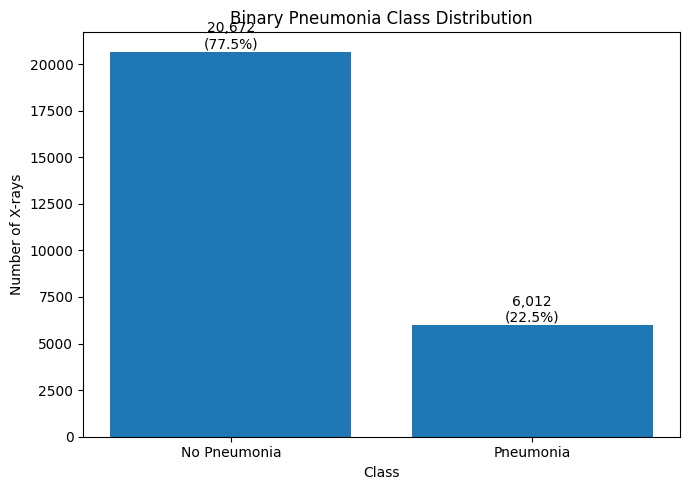

In [2]:
target_summary = (
    clean_df["Target"]
    .value_counts()
    .sort_index()
    .rename_axis("Target")
    .reset_index(name="count")
)

target_summary["class"] = target_summary["Target"].map({
    0: "No Pneumonia",
    1: "Pneumonia",
})
target_summary["percentage"] = (
    target_summary["count"] / len(clean_df) * 100
)

display(target_summary[["Target", "class", "count", "percentage"]])

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    target_summary["class"],
    target_summary["count"]
)

ax.set_title("Binary Pneumonia Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of X-rays")

for bar, count, pct in zip(
    bars,
    target_summary["count"],
    target_summary["percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "binary_class_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 2. Detailed Diagnostic-Class Distribution

The RSNA metadata distinguishes three diagnostic categories:

- `Normal`
- `No Lung Opacity / Not Normal`
- `Lung Opacity`

This is useful for understanding the heterogeneity inside the binary negative class.


,detailed_class,count,percentage
0,No Lung Opacity / Not Normal,11821,44.299955
1,Normal,8851,33.169690
2,Lung Opacity,6012,22.530355


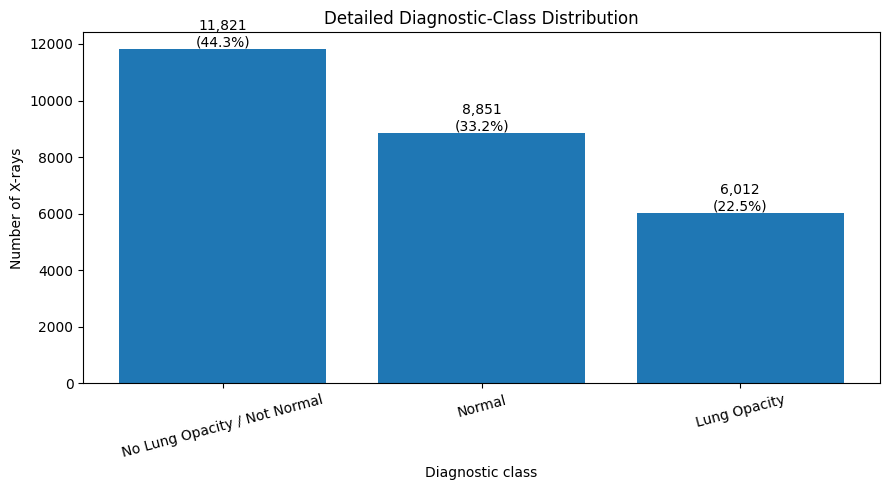

In [3]:
detailed_summary = (
    clean_df["detailed_class"]
    .value_counts()
    .rename_axis("detailed_class")
    .reset_index(name="count")
)

detailed_summary["percentage"] = (
    detailed_summary["count"] / len(clean_df) * 100
)

display(detailed_summary)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    detailed_summary["detailed_class"],
    detailed_summary["count"]
)

ax.set_title("Detailed Diagnostic-Class Distribution")
ax.set_xlabel("Diagnostic class")
ax.set_ylabel("Number of X-rays")
ax.tick_params(axis="x", rotation=15)

for bar, count, pct in zip(
    bars,
    detailed_summary["count"],
    detailed_summary["percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "detailed_class_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 3. Pneumonia Annotation Multiplicity

A pneumonia-positive X-ray may contain more than one annotated opacity region. Examine how many bounding boxes occur per positive image.


,num_pneumonia_boxes,patient_count,percentage
0,1,2614,43.479707
1,2,3266,54.324684
2,3,119,1.979375
3,4,13,0.216234


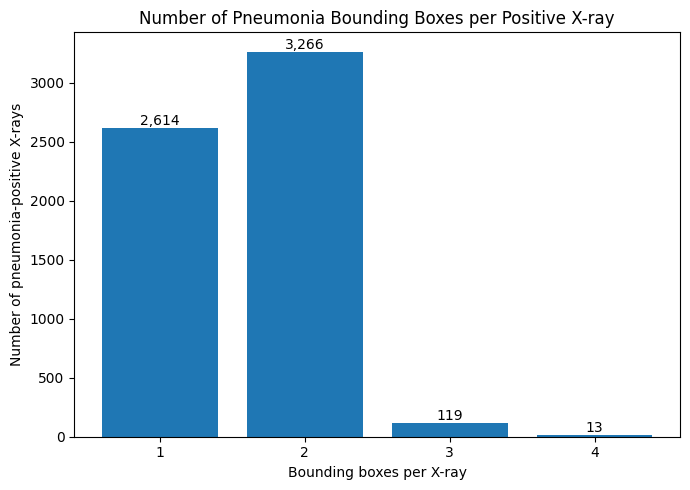

In [4]:
positive_patients = clean_df[clean_df["Target"] == 1].copy()

box_count_summary = (
    positive_patients["num_pneumonia_boxes"]
    .value_counts()
    .sort_index()
    .rename_axis("num_pneumonia_boxes")
    .reset_index(name="patient_count")
)

box_count_summary["percentage"] = (
    box_count_summary["patient_count"] / len(positive_patients) * 100
)

display(box_count_summary)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    box_count_summary["num_pneumonia_boxes"].astype(str),
    box_count_summary["patient_count"]
)

ax.set_title("Number of Pneumonia Bounding Boxes per Positive X-ray")
ax.set_xlabel("Bounding boxes per X-ray")
ax.set_ylabel("Number of pneumonia-positive X-rays")

for bar, count in zip(bars, box_count_summary["patient_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "pneumonia_box_count_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 4. Bounding-Box Size and Relative Area

Analyze the dimensions of pneumonia opacity annotations and the fraction of the chest X-ray occupied by each annotated region.


Read dimensions: 1500/6012
Read dimensions: 3000/6012
Read dimensions: 4500/6012
Read dimensions: 6000/6012
Read dimensions: 6012/6012


,width,height,box_area,relative_box_area
count,9555.000000,9555.000000,9555.000000,9555.000000
mean,218.471376,329.269702,77523.448038,0.073932
std,59.289475,157.750755,51807.689206,0.049408
min,40.000000,45.000000,2320.000000,0.002213
25%,177.000000,203.000000,37535.500000,0.035797
50%,217.000000,298.000000,64829.000000,0.061826
75%,259.000000,438.000000,106491.500000,0.101558
max,528.000000,942.000000,371184.000000,0.353989


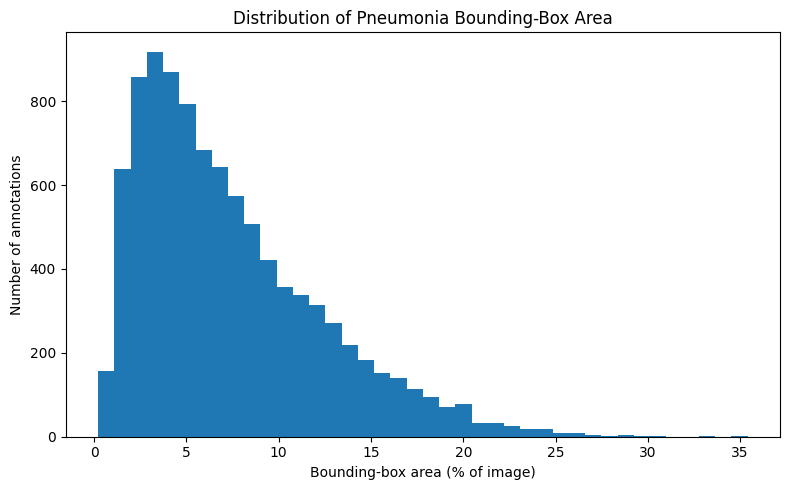

In [5]:
positive_boxes = labels_df[labels_df["Target"] == 1].copy()

# Image dimensions are required to express bounding-box area relative to image size.

positive_ids = positive_boxes["patientId"].unique()
dimensions = {}

for i, patient_id in enumerate(positive_ids, start=1):
    ds = pydicom.dcmread(
        TRAIN_IMAGE_DIR / f"{patient_id}.dcm",
        stop_before_pixels=True
    )
    dimensions[patient_id] = (int(ds.Columns), int(ds.Rows))

    if i % 1500 == 0 or i == len(positive_ids):
        print(f"Read dimensions: {i}/{len(positive_ids)}")

positive_boxes["image_width"] = positive_boxes["patientId"].map(
    lambda pid: dimensions[pid][0]
)
positive_boxes["image_height"] = positive_boxes["patientId"].map(
    lambda pid: dimensions[pid][1]
)

positive_boxes["box_area"] = (
    positive_boxes["width"] * positive_boxes["height"]
)
positive_boxes["image_area"] = (
    positive_boxes["image_width"] * positive_boxes["image_height"]
)
positive_boxes["relative_box_area"] = (
    positive_boxes["box_area"] / positive_boxes["image_area"]
)

bbox_stats = positive_boxes[
    ["width", "height", "box_area", "relative_box_area"]
].describe()

display(bbox_stats)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    positive_boxes["relative_box_area"] * 100,
    bins=40
)
ax.set_title("Distribution of Pneumonia Bounding-Box Area")
ax.set_xlabel("Bounding-box area (% of image)")
ax.set_ylabel("Number of annotations")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "relative_bbox_area_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 5. Representative X-rays by Diagnostic Class

Visualize raw chest X-rays from each detailed diagnostic category. These images are shown without preprocessing.


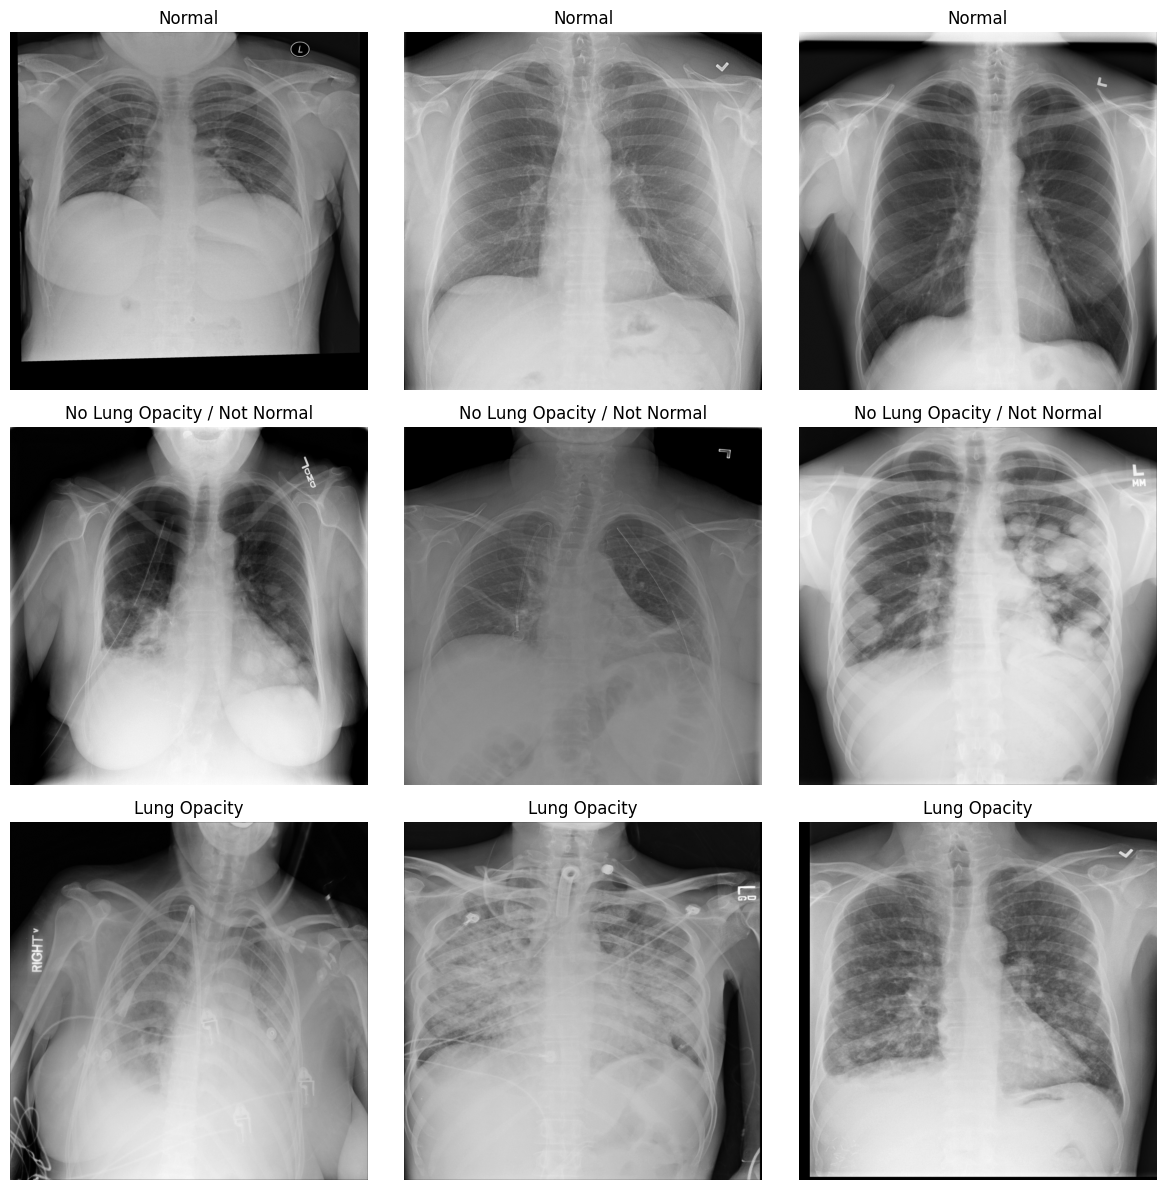

In [6]:
classes = [
    "Normal",
    "No Lung Opacity / Not Normal",
    "Lung Opacity",
]

examples_per_class = 3

fig, axes = plt.subplots(
    len(classes),
    examples_per_class,
    figsize=(12, 12)
)

for row_idx, class_name in enumerate(classes):
    examples = (
        clean_df[clean_df["detailed_class"] == class_name]
        .sort_values("patientId")
        .head(examples_per_class)
    )

    for col_idx, (_, row) in enumerate(examples.iterrows()):
        ax = axes[row_idx, col_idx]

        ds = pydicom.dcmread(
            TRAIN_IMAGE_DIR / row["image_filename"]
        )
        image = ds.pixel_array

        ax.imshow(image, cmap="gray")
        ax.set_title(class_name)
        ax.axis("off")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "examples_by_diagnostic_class.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 6. Pneumonia-Positive X-rays with Bounding Boxes

Visualize representative positive chest X-rays together with the original RSNA opacity annotations.


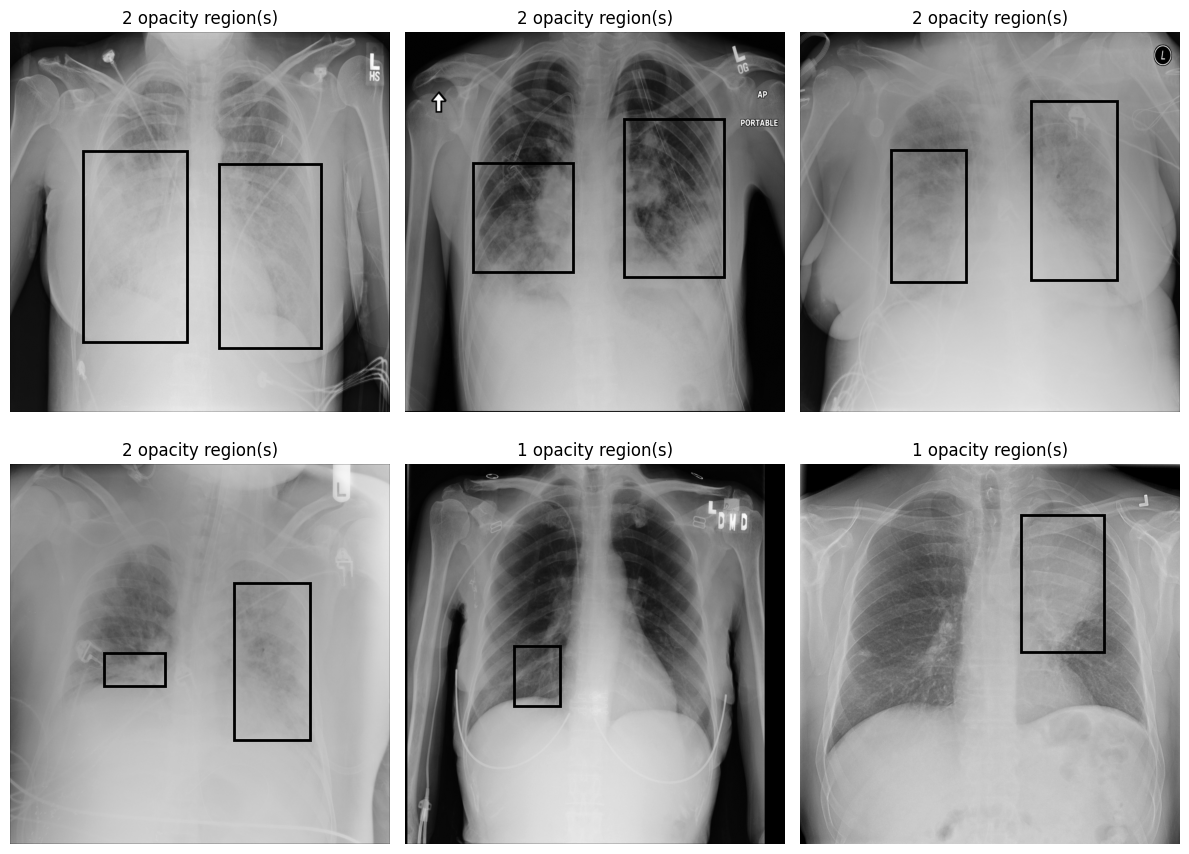

In [7]:
positive_examples = (
    clean_df[clean_df["Target"] == 1]
    .sample(n=6, random_state=42)
)

fig, axes = plt.subplots(2, 3, figsize=(12, 9))
axes = axes.ravel()

for ax, (_, row) in zip(axes, positive_examples.iterrows()):
    patient_id = row["patientId"]

    ds = pydicom.dcmread(
        TRAIN_IMAGE_DIR / row["image_filename"]
    )
    image = ds.pixel_array

    ax.imshow(image, cmap="gray")

    boxes = positive_boxes[
        positive_boxes["patientId"] == patient_id
    ]

    for _, box in boxes.iterrows():
        rectangle = plt.Rectangle(
            (box["x"], box["y"]),
            box["width"],
            box["height"],
            fill=False,
            linewidth=2,
        )
        ax.add_patch(rectangle)

    ax.set_title(f"{len(boxes)} opacity region(s)")
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "pneumonia_examples_with_boxes.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 7. Reproducible Pixel-Intensity Sample

Reading all 26,684 full-resolution DICOM images is unnecessary for exploratory intensity analysis. A reproducible stratified sample of 1,000 images is used to characterize raw pixel values while preserving the binary class proportions.


In [8]:
RANDOM_STATE = 42
SAMPLE_SIZE = 1000

sample_parts = []

for target, group in clean_df.groupby("Target"):
    n = round(SAMPLE_SIZE * len(group) / len(clean_df))
    sample_parts.append(
        group.sample(
            n=min(n, len(group)),
            random_state=RANDOM_STATE
        )
    )

intensity_sample = (
    pd.concat(sample_parts)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("Sample size:", len(intensity_sample))
print("\nSample target distribution:")
display(
    intensity_sample["Target"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

intensity_records = []

for i, row in intensity_sample.iterrows():
    ds = pydicom.dcmread(row["image_path"])
    pixels = ds.pixel_array.astype(np.float32)

    intensity_records.append({
        "patientId": row["patientId"],
        "Target": row["Target"],
        "detailed_class": row["detailed_class"],
        "pixel_min": float(pixels.min()),
        "pixel_max": float(pixels.max()),
        "pixel_mean": float(pixels.mean()),
        "pixel_std": float(pixels.std()),
    })

    if (i + 1) % 200 == 0 or (i + 1) == len(intensity_sample):
        print(f"Processed images: {i + 1}/{len(intensity_sample)}")

intensity_df = pd.DataFrame(intensity_records)
display(intensity_df.head())

Sample size: 1000

Sample target distribution:


,count
Target,
0,775
1,225


KeyError: 'image_path'

## 8. Raw Intensity Characteristics by Binary Class

Compare sampled per-image mean intensity and contrast (pixel standard deviation) between pneumonia-positive and pneumonia-negative images.

These are descriptive raw-image statistics only and are not used as classification features.


pixel_mean                         pixel_std                       pixel_min                    pixel_max                  
              mean        std      median       mean        std     median      mean       std median        mean        std median
Target                                                                                                                             
0       124.397672  22.355132  120.027885  58.277245  11.522547  60.708607  0.491613  2.568869    0.0  247.283871  16.818592  255.0
1       124.010434  21.888999  119.492111  55.435508  10.403592  54.913315  0.355556  1.997270    0.0  248.320000  13.579291  255.0

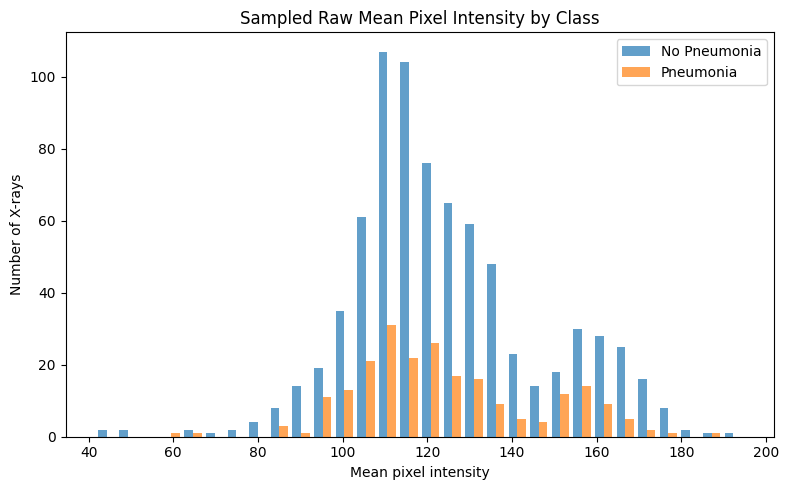

In [ ]:
intensity_class_summary = (
    intensity_df.groupby("Target")[
        ["pixel_mean", "pixel_std", "pixel_min", "pixel_max"]
    ]
    .agg(["mean", "std", "median"])
)

display(intensity_class_summary)

fig, ax = plt.subplots(figsize=(8, 5))

negative_means = intensity_df.loc[
    intensity_df["Target"] == 0, "pixel_mean"
]
positive_means = intensity_df.loc[
    intensity_df["Target"] == 1, "pixel_mean"
]

ax.hist(
    [negative_means, positive_means],
    bins=30,
    label=["No Pneumonia", "Pneumonia"]
)

ax.set_title("Sampled Raw Mean Pixel Intensity by Class")
ax.set_xlabel("Mean pixel intensity")
ax.set_ylabel("Number of X-rays")
ax.legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "mean_intensity_by_binary_class.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 9. EDA Summary

In [ ]:
num_negative = int((clean_df["Target"] == 0).sum())
num_positive = int((clean_df["Target"] == 1).sum())

eda_summary = pd.DataFrame({
    "metric": [
        "Total chest X-rays",
        "Pneumonia-positive X-rays",
        "Pneumonia-negative X-rays",
        "Pneumonia prevalence",
        "Detailed diagnostic classes",
        "Positive bounding-box annotations",
        "Positive X-rays with multiple opacity boxes",
        "Median relative bounding-box area",
        "Intensity-analysis sample size",
    ],
    "value": [
        f"{len(clean_df):,}",
        f"{num_positive:,}",
        f"{num_negative:,}",
        f"{num_positive / len(clean_df) * 100:.2f}%",
        f"{clean_df['detailed_class'].nunique()}",
        f"{len(positive_boxes):,}",
        f"{int((clean_df['num_pneumonia_boxes'] > 1).sum()):,}",
        f"{positive_boxes['relative_box_area'].median() * 100:.2f}%",
        f"{len(intensity_df):,}",
    ],
})

display(eda_summary)

,metric,value
0,Total chest X-rays,26684.000000
1,Pneumonia-positive X-rays,6012.000000
2,Pneumonia-negative X-rays,20672.000000
3,Pneumonia prevalence (%),22.530355
4,Detailed diagnostic classes,3.000000
5,Positive bounding-box annotations,9555.000000
6,Positive X-rays with multiple opacity boxes,3398.000000
7,Median relative bounding-box area (%),6.182575
8,Intensity-analysis sample size,1000.000000



EDA outputs saved to:
E:\Projects\CNN and Vision Transformer-Based Pneumonia Classification in Chest X-Rays\outputs\eda

EXPLORATORY DATA ANALYSIS COMPLETE
